# Overlap Variation Analysis: Energy Barrier vs Overlap Length

This notebook investigates the hypothesis that **energy barriers increase with increasing gene overlap**.

## Approach:
1. For each overlap value, generate a small pool of functional sequences
2. Select the pair with lowest Hamming distance (easiest evolutionary path)
3. Use Genetic Algorithm to find optimal mutation ordering
4. Record the maximum energy barrier along the path
5. Plot energy barrier vs overlap to test the hypothesis

## 1. Setup and Imports

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit
from tqdm.auto import tqdm
import pandas as pd
import gc
import warnings
import os
import pickle
from multiprocessing import Pool
from functools import partial
warnings.filterwarnings('ignore')

# Import local module
import overlappingGenes as og

# Import worker module for multiprocessing
from ga_worker import (
    process_overlap_trial,
    GeneticPathFinder,
    find_closest_pair,
    find_pair_with_target_hamming,
    hamming_distance,
    get_path_energies
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Reproducibility (base seed - each trial gets unique seed)
np.random.seed(42)

## 2. Load DCA Parameters

In [21]:
PROTEIN_1 = 'PF00004'
PROTEIN_2 = 'PF00041'

print(f"Loading DCA parameters for {PROTEIN_1}...")
Jvec_1, hvec_1 = og.extract_params(f'{PROTEIN_1}/{PROTEIN_1}_params.dat')
nat_energies_1 = og.load_natural_energies(f'{PROTEIN_1}/{PROTEIN_1}_naturalenergies.txt')
mean_e1, std_e1 = np.mean(nat_energies_1), np.std(nat_energies_1)
print(f"  Length: {len(hvec_1)//21} AA, Mean energy: {mean_e1:.2f} ± {std_e1:.2f}")

print(f"\nLoading DCA parameters for {PROTEIN_2}...")
Jvec_2, hvec_2 = og.extract_params(f'{PROTEIN_2}/{PROTEIN_2}_params.dat')
nat_energies_2 = og.load_natural_energies(f'{PROTEIN_2}/{PROTEIN_2}_naturalenergies.txt')
mean_e2, std_e2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"  Length: {len(hvec_2)//21} AA, Mean energy: {mean_e2:.2f} ± {std_e2:.2f}")

DCA_params_1 = (Jvec_1, hvec_1)
DCA_params_2 = (Jvec_2, hvec_2)

prot1_len = len(hvec_1) // 21
prot2_len = len(hvec_2) // 21
print(f"\nProtein 1 length: {prot1_len} AA")
print(f"Protein 2 length: {prot2_len} AA")

Loading DCA parameters for PF00004...
  Length: 110 AA, Mean energy: 145.88 ± 38.25

Loading DCA parameters for PF00041...
  Length: 74 AA, Mean energy: 120.66 ± 17.64

Protein 1 length: 110 AA
Protein 2 length: 74 AA


## 3. Configuration

In [22]:
# Overlap values to scan (nucleotides)
# Start at 12 (minimum reliable), go up to 60 in steps of 6
OVERLAPS = list(range(12, 192, 12))

# Sequence generation parameters
N_SEQUENCES = 15       # Sequences per batch (generates more if needed for target Hamming)
MC_ITERATIONS = 150_000  # MC iterations per sequence
MC_TEMP_1 = 0.818
MC_TEMP_2 = 0.955

# Genetic Algorithm parameters
GA_POPULATION = 100
GA_GENERATIONS = 120

# --- NORMALIZATION ---
Z_SCORE = True               # If True, normalize distances using z-scores

# === HAMMING DISTANCE CONTROL ===
# Set TARGET_HAMMING to enforce constant Hamming distance across all overlaps
# Set to None to use original "closest pair" behavior (variable Hamming)
TARGET_HAMMING = 240          # Target Hamming distance for all overlaps (None = closest pair)
HAMMING_TOLERANCE = 0        # Accept pairs within ±tolerance of target
MAX_SEQUENCES = 100           # Max sequences to generate before giving up

# === REPEAT & PARALLELIZATION SETTINGS ===
N_REPEATS = 20                          # Independent trials per overlap
N_WORKERS = max(1, os.cpu_count() - 1)  # Auto-detect workers (leave 1 core free)
CHECKPOINT_FREQ = 20                    # Save checkpoint every N work units
CHECKPOINT_FILE = 'ga_variation_checkpoint.pkl'

# Dynamic plot labels based on Z_SCORE
DIST_LABEL = "Z-Score Distance" if Z_SCORE else "Distance from Natural"
MAX_DIST_LABEL = "Max Z-Score Distance" if Z_SCORE else "Max Distance from Natural"

print(f"Overlaps to scan: {len(OVERLAPS)} values ({min(OVERLAPS)}-{max(OVERLAPS)})")
print(f"Sequences per batch: {N_SEQUENCES}")
print(f"MC iterations: {MC_ITERATIONS:,}")
print(f"GA: {GA_POPULATION} pop x {GA_GENERATIONS} gen")
print(f"Z-Score normalization: {Z_SCORE}")
print(f"\n=== Hamming Distance Control ===")
if TARGET_HAMMING is not None:
    print(f"Target Hamming: {TARGET_HAMMING} ± {HAMMING_TOLERANCE}")
    print(f"Max sequences to generate: {MAX_SEQUENCES}")
else:
    print("Mode: Closest pair (variable Hamming)")
print(f"\n=== Parallelization ===")
print(f"Repeats per overlap: {N_REPEATS}")
print(f"Total work units: {len(OVERLAPS) * N_REPEATS}")
print(f"Workers: {N_WORKERS}")
print(f"Checkpoint frequency: every {CHECKPOINT_FREQ} units")

Overlaps to scan: 15 values (12-180)
Sequences per batch: 15
MC iterations: 150,000
GA: 100 pop x 120 gen
Z-Score normalization: True

=== Hamming Distance Control ===
Target Hamming: 240 ± 0
Max sequences to generate: 100

=== Parallelization ===
Repeats per overlap: 20
Total work units: 300
Workers: 15
Checkpoint frequency: every 20 units


## 4. Core Functions

In [23]:
# =============================================================================
# LOCAL HELPER FUNCTIONS (for warmup and single-sequence operations)
# Main GA functions are imported from ga_worker.py for multiprocessing
# =============================================================================

def generate_functional_sequence(overlap, n_iterations=200_000):
    """Generate a single functional overlapping sequence using MC relaxation."""
    initial_seq = og.initial_seq_no_stops(prot1_len, prot2_len, overlap, quiet=True)

    result = og.overlapped_sequence_generator_int(
        DCA_params_1, DCA_params_2, initial_seq,
        T1=MC_TEMP_1, T2=MC_TEMP_2,
        numberofiterations=n_iterations,
        quiet=True,
        whentosave=100.0,
        nat_mean1=mean_e1,
        nat_mean2=mean_e2,
        nat_std1=std_e1,
        nat_std2=std_e2,
        use_z_score=Z_SCORE
    )

    best_seq = result[6]
    best_energies = result[5]

    return best_seq, best_energies


@njit
def calculate_total_energy(seq_str, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2):
    """Calculate total energy (E1 + E2) for an overlapping sequence."""
    Jvec1, hvec1 = DCA_params_1
    Jvec2, hvec2 = DCA_params_2

    seq = og.seq_str_to_int_array(seq_str)
    len_seq_1_n = len_aa_1 * 3
    len_seq_2_n = len_aa_2 * 3

    aa_seq_1 = np.empty(len_aa_1, dtype=np.int32)
    aa_seq_2 = np.empty(len_aa_2, dtype=np.int32)
    rc_buffer = np.empty(len_seq_2_n, dtype=np.uint8)

    og.split_sequence_and_to_numeric_out(seq, len_seq_1_n, len_seq_2_n, aa_seq_1, aa_seq_2, rc_buffer)

    for i in range(len_aa_1 - 1):
        if aa_seq_1[i] == 21:
            return np.inf
    for i in range(len_aa_2 - 1):
        if aa_seq_2[i] == 21:
            return np.inf

    E1 = og.calculate_Energy(aa_seq_1[:-1], Jvec1, hvec1)
    E2 = og.calculate_Energy(aa_seq_2[:-1], Jvec2, hvec2)

    return E1 + E2


# =============================================================================
# CHECKPOINT FUNCTIONS
# =============================================================================

def save_checkpoint(completed, remaining, filepath):
    """Save progress to checkpoint file."""
    with open(filepath, 'wb') as f:
        pickle.dump({'completed': completed, 'remaining': remaining}, f)
    print(f"  Checkpoint saved: {len(completed)} done, {len(remaining)} remaining")


def load_checkpoint(filepath):
    """Load progress from checkpoint file."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data['completed'], data['remaining']

In [24]:
# GeneticPathFinder and get_path_energies are now imported from ga_worker.py
# This keeps the notebook clean and enables Windows-compatible multiprocessing

print("Core GA functions loaded from ga_worker.py")
print(f"  - GeneticPathFinder: GA optimizer for mutation path ordering")
print(f"  - process_overlap_trial: Worker function for parallel execution")
print(f"  - find_closest_pair: Finds minimum Hamming distance pair")
print(f"  - hamming_distance: Sequence comparison")

Core GA functions loaded from ga_worker.py
  - GeneticPathFinder: GA optimizer for mutation path ordering
  - process_overlap_trial: Worker function for parallel execution
  - find_closest_pair: Finds minimum Hamming distance pair
  - hamming_distance: Sequence comparison


## 5. JIT Warmup

In [25]:
print("Warming up JIT compilation...")

# Warmup with a quick sequence generation
warmup_overlap = 12
warmup_seq, _ = generate_functional_sequence(warmup_overlap, n_iterations=1000)

# Warmup energy calculation
len_aa_1 = prot1_len + 1
len_aa_2 = prot2_len + 1
_ = calculate_total_energy(warmup_seq, DCA_params_1, DCA_params_2, len_aa_1, len_aa_2)

# Warmup worker module functions (needed for multiprocessing)
from ga_worker import calculate_energies_separate, seq_to_array
warmup_arr = seq_to_array(warmup_seq)
_ = calculate_energies_separate(warmup_arr, Jvec_1, hvec_1, Jvec_2, hvec_2, len_aa_1, len_aa_2)

print("JIT compilation complete!")
del warmup_seq, warmup_arr
gc.collect()

Warming up JIT compilation...
JIT compilation complete!


12707

## 6. Sequence Pair Generation

This cell generates all sequence pairs before running the GA optimization. This allows tracking progress of the generation task separately from the GA analysis.

In [26]:
# =============================================================================
# PARALLEL SEQUENCE GENERATION
# =============================================================================
from ga_worker import generate_single_sequence
from collections import defaultdict

# Build ALL work units upfront
all_seq_work_units = []
for overlap in OVERLAPS:
    for trial in range(N_REPEATS):
        base_seed = 42 + overlap * 1000 + trial * 100
        for seq_idx in range(N_SEQUENCES):
            seed = base_seed + seq_idx
            all_seq_work_units.append((
                overlap, trial, seq_idx, seed,
                Jvec_1, hvec_1, Jvec_2, hvec_2,
                prot1_len, prot2_len,
                MC_ITERATIONS, MC_TEMP_1, MC_TEMP_2,
                mean_e1, mean_e2, std_e1, std_e2, Z_SCORE
            ))

print(f"Generating {len(all_seq_work_units)} sequences across {len(OVERLAPS)} overlaps...")
print(f"Using {N_WORKERS} parallel workers")
print(f"Sequences per (overlap, trial): {N_SEQUENCES}")
print("=" * 60)

# Single pool for ALL sequences - parallel execution
with Pool(N_WORKERS) as pool:
    all_results = list(tqdm(
        pool.imap(generate_single_sequence, all_seq_work_units),
        total=len(all_seq_work_units),
        desc="Generating sequences"
    ))

print(f"\nGeneration complete. Processing results...")

# Group results by (overlap, trial)
grouped = defaultdict(list)
for r in all_results:
    if r['success']:
        grouped[(r['overlap'], r['trial'])].append(r)

# Track generation statistics
generation_stats = {
    'total_attempts': len(all_seq_work_units),
    'failed_attempts': sum(1 for r in all_results if not r['success']),
    'total_sequences': sum(1 for r in all_results if r['success']),
    'successful_pairs': 0,
    'failed_pairs': 0,
    'by_overlap': {}
}

# Build generated_pairs dict (same format as before)
generated_pairs = {}
for (overlap, trial), seq_list in grouped.items():
    sequences = [r['sequence'] for r in seq_list]
    energies = np.array([r['energies'] for r in seq_list])
    
    # Track per-overlap statistics
    if overlap not in generation_stats['by_overlap']:
        generation_stats['by_overlap'][overlap] = {
            'attempts': 0, 'sequences': 0, 'successes': 0, 'failures': 0,
            'hamming_distances': []
        }
    generation_stats['by_overlap'][overlap]['sequences'] += len(sequences)
    generation_stats['by_overlap'][overlap]['attempts'] += N_SEQUENCES

    # Need at least 2 sequences to form a pair
    if len(sequences) < 2:
        generation_stats['failed_pairs'] += 1
        generation_stats['by_overlap'][overlap]['failures'] += 1
        continue

    # Find best pair based on Hamming distance criteria
    if TARGET_HAMMING is not None:
        pair_result = find_pair_with_target_hamming(sequences, TARGET_HAMMING, HAMMING_TOLERANCE)
        if pair_result:
            p1, p2, ham_dist = pair_result
            # Check if within tolerance
            if abs(ham_dist - TARGET_HAMMING) > HAMMING_TOLERANCE:
                # Need more sequences - for now, use best available
                pass
        else:
            generation_stats['failed_pairs'] += 1
            generation_stats['by_overlap'][overlap]['failures'] += 1
            continue
    else:
        (p1, p2), ham_dist = find_closest_pair(sequences)

    generated_pairs[(overlap, trial)] = {
        'overlap': overlap,
        'trial': trial,
        'seed': 42 + overlap * 1000 + trial * 100,
        'success': True,
        'sequences': sequences,
        'energies': energies,
        'pair_indices': (p1, p2),
        'hamming_distance': ham_dist,
        'total_attempts': N_SEQUENCES,
        'failed_attempts': N_SEQUENCES - len(sequences),
        'sequences_generated': len(sequences)
    }
    
    generation_stats['successful_pairs'] += 1
    generation_stats['by_overlap'][overlap]['successes'] += 1
    generation_stats['by_overlap'][overlap]['hamming_distances'].append(ham_dist)

print("\n" + "=" * 60)
print("SEQUENCE GENERATION COMPLETE")
print("=" * 60)
print(f"Total sequences generated: {generation_stats['total_sequences']}")
print(f"Failed generation attempts: {generation_stats['failed_attempts']}")
print(f"Successful pairs: {generation_stats['successful_pairs']}")
print(f"Failed pairs: {generation_stats['failed_pairs']}")

Generating 4500 sequences across 15 overlaps...
Using 15 parallel workers
Sequences per (overlap, trial): 15


Generating sequences: 100%|██████████| 4500/4500 [02:52<00:00, 26.03it/s]



Generation complete. Processing results...

SEQUENCE GENERATION COMPLETE
Total sequences generated: 4500
Failed generation attempts: 0
Successful pairs: 300
Failed pairs: 0


In [27]:
# =============================================================================
# GENERATION STATISTICS & DIFFICULTY ANALYSIS
# =============================================================================

print("\n=== GENERATION STATISTICS ===")
print(f"Total sequence pairs attempted: {len(work_units)}")
print(f"Successful pairs: {generation_stats['successful_pairs']}")
print(f"Failed pairs: {generation_stats['failed_pairs']}")
print(f"Overall success rate: {generation_stats['successful_pairs']/len(work_units)*100:.1f}%")
print(f"\nTotal sequences generated: {generation_stats['total_sequences']}")
print(f"Total generation attempts: {generation_stats['total_attempts']}")
print(f"Failed attempts: {generation_stats['failed_attempts']}")
print(f"Attempt success rate: {(generation_stats['total_attempts']-generation_stats['failed_attempts'])/generation_stats['total_attempts']*100:.1f}%")

# Per-overlap difficulty analysis
print("\n=== DIFFICULTY BY OVERLAP ===")
print("-" * 80)
print(f"{'Overlap':>8} | {'Seqs/Pair':>10} | {'Attempts':>10} | {'Success':>8} | {'Mean Ham':>10} | {'Difficulty':>10}")
print("-" * 80)

difficulty_data = []
for overlap in OVERLAPS:
    stats = generation_stats['by_overlap'].get(overlap, {})
    n_trials = stats.get('successes', 0) + stats.get('failures', 0)
    if n_trials == 0:
        continue
    
    seqs_per_pair = stats['sequences'] / n_trials if n_trials > 0 else 0
    attempts_per_pair = stats['attempts'] / n_trials if n_trials > 0 else 0
    success_rate = stats['successes'] / n_trials * 100 if n_trials > 0 else 0
    mean_ham = np.mean(stats['hamming_distances']) if stats['hamming_distances'] else np.nan
    
    # Difficulty score: higher = harder (more attempts needed per successful pair)
    difficulty = attempts_per_pair / (success_rate / 100) if success_rate > 0 else np.inf
    
    difficulty_data.append({
        'overlap': overlap,
        'seqs_per_pair': seqs_per_pair,
        'attempts_per_pair': attempts_per_pair,
        'success_rate': success_rate,
        'mean_hamming': mean_ham,
        'difficulty': difficulty
    })
    
    print(f"  {overlap:6d} | {seqs_per_pair:10.1f} | {attempts_per_pair:10.1f} | {success_rate:7.1f}% | {mean_ham:10.1f} | {difficulty:10.2f}")

print("-" * 80)

# Create difficulty DataFrame
difficulty_df = pd.DataFrame(difficulty_data)

# Plot difficulty metrics
if len(difficulty_data) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot 1: Sequences needed per pair
    ax1 = axes[0]
    ax1.bar(difficulty_df['overlap'], difficulty_df['seqs_per_pair'], color='steelblue', edgecolor='black')
    ax1.set_xlabel('Overlap (nucleotides)')
    ax1.set_ylabel('Sequences Generated per Pair')
    ax1.set_title('Generation Effort by Overlap')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Success rate
    ax2 = axes[1]
    ax2.bar(difficulty_df['overlap'], difficulty_df['success_rate'], color='green', edgecolor='black')
    ax2.set_xlabel('Overlap (nucleotides)')
    ax2.set_ylabel('Success Rate (%)')
    ax2.set_title('Pair Generation Success Rate')
    ax2.set_ylim(0, 105)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Difficulty score
    ax3 = axes[2]
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(difficulty_df)))
    ax3.bar(difficulty_df['overlap'], difficulty_df['difficulty'], color=colors, edgecolor='black')
    ax3.set_xlabel('Overlap (nucleotides)')
    ax3.set_ylabel('Difficulty Score')
    ax3.set_title('Generation Difficulty (attempts/success)')
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('sequence_generation_difficulty.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Correlation between overlap and difficulty
    if len(difficulty_df) > 2:
        from scipy import stats as sp_stats
        corr, p_val = sp_stats.spearmanr(difficulty_df['overlap'], difficulty_df['difficulty'])
        print(f"\nCorrelation (overlap vs difficulty): {corr:.3f} (p={p_val:.4f})")
        if p_val < 0.05:
            if corr > 0:
                print("→ Significant positive correlation: higher overlap = harder to generate pairs")
            else:
                print("→ Significant negative correlation: higher overlap = easier to generate pairs")
        else:
            print("→ No significant correlation between overlap and generation difficulty")


=== GENERATION STATISTICS ===


NameError: name 'work_units' is not defined

## 7. GA Optimization Loop

Using pre-generated sequence pairs, run the Genetic Algorithm to find optimal mutation orderings.

In [28]:
# =============================================================================
# GA OPTIMIZATION USING PRE-GENERATED PAIRS
# =============================================================================

# Filter to only successful pairs
successful_pairs = {k: v for k, v in generated_pairs.items() if v['success']}
print(f"Running GA optimization on {len(successful_pairs)} pre-generated sequence pairs...")
print(f"Optimizing for: MINIMUM DISTANCE from natural means")
if Z_SCORE:
    print(f"Distance metric (Z-SCORE): |z1| + |z2| where z = (E - mean) / std")
else:
    print(f"Distance metric: |E1 - {mean_e1:.2f}| + |E2 - {mean_e2:.2f}|")
print("=" * 60)

# Calculate lengths
len_aa_1 = prot1_len + 1
len_aa_2 = prot2_len + 1

# Run GA on each pre-generated pair
raw_results = []
pbar = tqdm(successful_pairs.items(), desc="GA Optimization", unit="pair")

for (overlap, trial), pair_data in pbar:
    # Get the sequence pair
    p1, p2 = pair_data['pair_indices']
    seq_start = pair_data['sequences'][p1]
    seq_end = pair_data['sequences'][p2]
    energies = pair_data['energies']
    ham_dist = pair_data['hamming_distance']
    
    # Run Genetic Algorithm
    ga = GeneticPathFinder(
        seq_start, seq_end,
        Jvec_1, hvec_1, Jvec_2, hvec_2, len_aa_1, len_aa_2,
        nat_mean_1=mean_e1, nat_mean_2=mean_e2,
        nat_std_1=std_e1, nat_std_2=std_e2, z_score=Z_SCORE,
        pop_size=GA_POPULATION, n_generations=GA_GENERATIONS
    )
    
    best_order, max_distance, path_energies, path_distances = ga.run(verbose=False)
    
    # Determine if GA converged
    ga_converged = (len(ga.fitness_history) > 1 and
                    ga.fitness_history[-1] < ga.fitness_history[0])
    
    result = {
        'overlap': overlap,
        'trial': trial,
        'seed': pair_data['seed'],
        'error': None,
        'hamming_distance': ham_dist,
        'n_mutations': len(ga.mutations),
        'max_distance_from_natural': max_distance,
        'start_distance': path_distances[0] if len(path_distances) > 0 else np.nan,
        'end_distance': path_distances[-1] if len(path_distances) > 0 else np.nan,
        'start_energy': path_energies[0] if len(path_energies) > 0 else np.nan,
        'end_energy': path_energies[-1] if len(path_energies) > 0 else np.nan,
        'mean_e1_generated': energies[:, 0].mean(),
        'mean_e2_generated': energies[:, 1].mean(),
        'ga_converged': ga_converged
    }
    raw_results.append(result)
    
    # Update progress bar
    pbar.set_postfix({
        'overlap': overlap,
        'max_dist': f"{max_distance:.3f}",
        'converged': ga_converged
    })

print("\n" + "=" * 60)
print(f"GA optimization complete! {len(raw_results)} results collected.")

# Count any issues
errors = [r for r in raw_results if r.get('error') is not None]
if errors:
    print(f"  Warning: {len(errors)} trials had errors")

Running GA optimization on 300 pre-generated sequence pairs...
Optimizing for: MINIMUM DISTANCE from natural means
Distance metric (Z-SCORE): |z1| + |z2| where z = (E - mean) / std


GA Optimization:   3%|▎         | 10/300 [04:09<2:00:40, 24.97s/pair, overlap=12, max_dist=0.230, converged=True]


RuntimeError: Could not generate stop-codon-free path after 1000 attempts. The sequence pair may not have any valid evolutionary paths.

In [ ]:
# =============================================================================
# RESULT AGGREGATION
# =============================================================================

# Convert raw results to DataFrame
raw_df = pd.DataFrame(raw_results)

# Filter out errors
valid_df = raw_df[raw_df['error'].isna()].copy()
print(f"Valid results: {len(valid_df)} / {len(raw_df)} ({100*len(valid_df)/len(raw_df):.1f}%)")

# Aggregate across repeats for each overlap
summary = valid_df.groupby('overlap').agg({
    'max_distance_from_natural': ['mean', 'std', 'min', 'max', 'count'],
    'hamming_distance': ['mean', 'std'],
    'start_distance': ['mean', 'std'],
    'end_distance': ['mean', 'std'],
    'n_mutations': ['mean', 'std'],
    'mean_e1_generated': ['mean', 'std'],
    'mean_e2_generated': ['mean', 'std'],
    'ga_converged': ['sum', 'count']
}).round(4)

# Flatten column names
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

# Calculate convergence rate
summary['ga_convergence_rate'] = summary['ga_converged_sum'] / summary['ga_converged_count']

# Calculate relative distance (barrier above starting point)
summary['relative_distance_mean'] = summary['max_distance_from_natural_mean'] - summary['start_distance_mean']

# Create legacy-compatible 'results' list for visualization code
results = []
for _, row in summary.iterrows():
    results.append({
        'overlap': row['overlap'],
        'hamming_distance': row['hamming_distance_mean'],
        'n_mutations': row['n_mutations_mean'],
        'max_distance_from_natural': row['max_distance_from_natural_mean'],
        'max_distance_std': row['max_distance_from_natural_std'],
        'start_distance': row['start_distance_mean'],
        'end_distance': row['end_distance_mean'],
        'start_energy': np.nan,  # Not stored in aggregated form
        'end_energy': np.nan,
        'path_energies': np.array([]),  # Not stored
        'path_distances': np.array([]),  # Not stored
        'fitness_history': [],  # Not stored
        'mean_e1': row['mean_e1_generated_mean'],
        'mean_e2': row['mean_e2_generated_mean'],
        'n_trials': row['max_distance_from_natural_count'],
        'convergence_rate': row['ga_convergence_rate']
    })

print(f"\nAggregated {len(results)} overlap values")
print("\nSummary statistics:")
display(summary[['overlap', 'max_distance_from_natural_mean', 'max_distance_from_natural_std', 
                 'hamming_distance_mean', 'ga_convergence_rate', 'max_distance_from_natural_count']])

Valid results: 180 / 180 (100.0%)

Aggregated 9 overlap values

Summary statistics:


,overlap,max_distance_from_natural_mean,max_distance_from_natural_std,hamming_distance_mean,ga_convergence_rate,max_distance_from_natural_count
0,12,0.2443,0.0490,262.20,1.00,20
1,18,inf,NaN,258.60,0.95,20
2,24,0.2363,0.0418,254.20,1.00,20
3,30,0.2333,0.0421,248.40,1.00,20
4,36,0.2310,0.0322,243.85,1.00,20
5,42,0.2174,0.0334,241.30,1.00,20
6,48,0.2358,0.0340,240.85,1.00,20
7,54,0.4049,0.2129,240.60,1.00,20
8,60,0.2375,0.0429,239.95,1.00,20


## 8. Results Visualization

In [ ]:
if len(results) == 0:
    print("No results to plot.")
else:
    # Extract data for plotting
    overlaps = [int(r['overlap']) for r in results]  # Convert to int
    max_distances = [r['max_distance_from_natural'] for r in results]
    max_dist_stds = [r.get('max_distance_std', 0) for r in results]
    ham_dists = [r['hamming_distance'] for r in results]
    start_distances = [r['start_distance'] for r in results]
    n_trials_list = [int(r.get('n_trials', 1)) for r in results]  # Convert to int
    
    # Calculate relative distance (distance above starting distance)
    relative_distances = [m - s for m, s in zip(max_distances, start_distances)]
    
    print(f"\nResults Summary (DISTANCE FROM NATURAL MEANS) - {N_REPEATS} repeats per overlap:")
    print("-" * 85)
    print(f"{'Overlap':>8} | {'Max Dist Mean':>13} | {'Std':>8} | {'Relative':>10} | {'Hamming':>8} | {'n':>5}")
    print("-" * 85)
    for r in results:
        rel_dist = r['max_distance_from_natural'] - r['start_distance']
        std = r.get('max_distance_std', 0)
        n = int(r.get('n_trials', 1))
        ov = int(r['overlap'])
        print(f"  {ov:6d} | {r['max_distance_from_natural']:13.4f} | {std:8.4f} | {rel_dist:10.4f} | {r['hamming_distance']:8.1f} | {n:5d}")


Results Summary (DISTANCE FROM NATURAL MEANS) - 20 repeats per overlap:
-------------------------------------------------------------------------------------
 Overlap | Max Dist Mean |      Std |   Relative |  Hamming |     n
-------------------------------------------------------------------------------------
      12 |        0.2443 |   0.0490 |     0.2367 |    262.2 |    20
      18 |           inf |      nan |        inf |    258.6 |    20
      24 |        0.2363 |   0.0418 |     0.2286 |    254.2 |    20
      30 |        0.2333 |   0.0421 |     0.2192 |    248.4 |    20
      36 |        0.2310 |   0.0322 |     0.2215 |    243.8 |    20
      42 |        0.2174 |   0.0334 |     0.2033 |    241.3 |    20
      48 |        0.2358 |   0.0340 |     0.2154 |    240.8 |    20
      54 |        0.4049 |   0.2129 |     0.2598 |    240.6 |    20
      60 |        0.2375 |   0.0429 |     0.2256 |    239.9 |    20


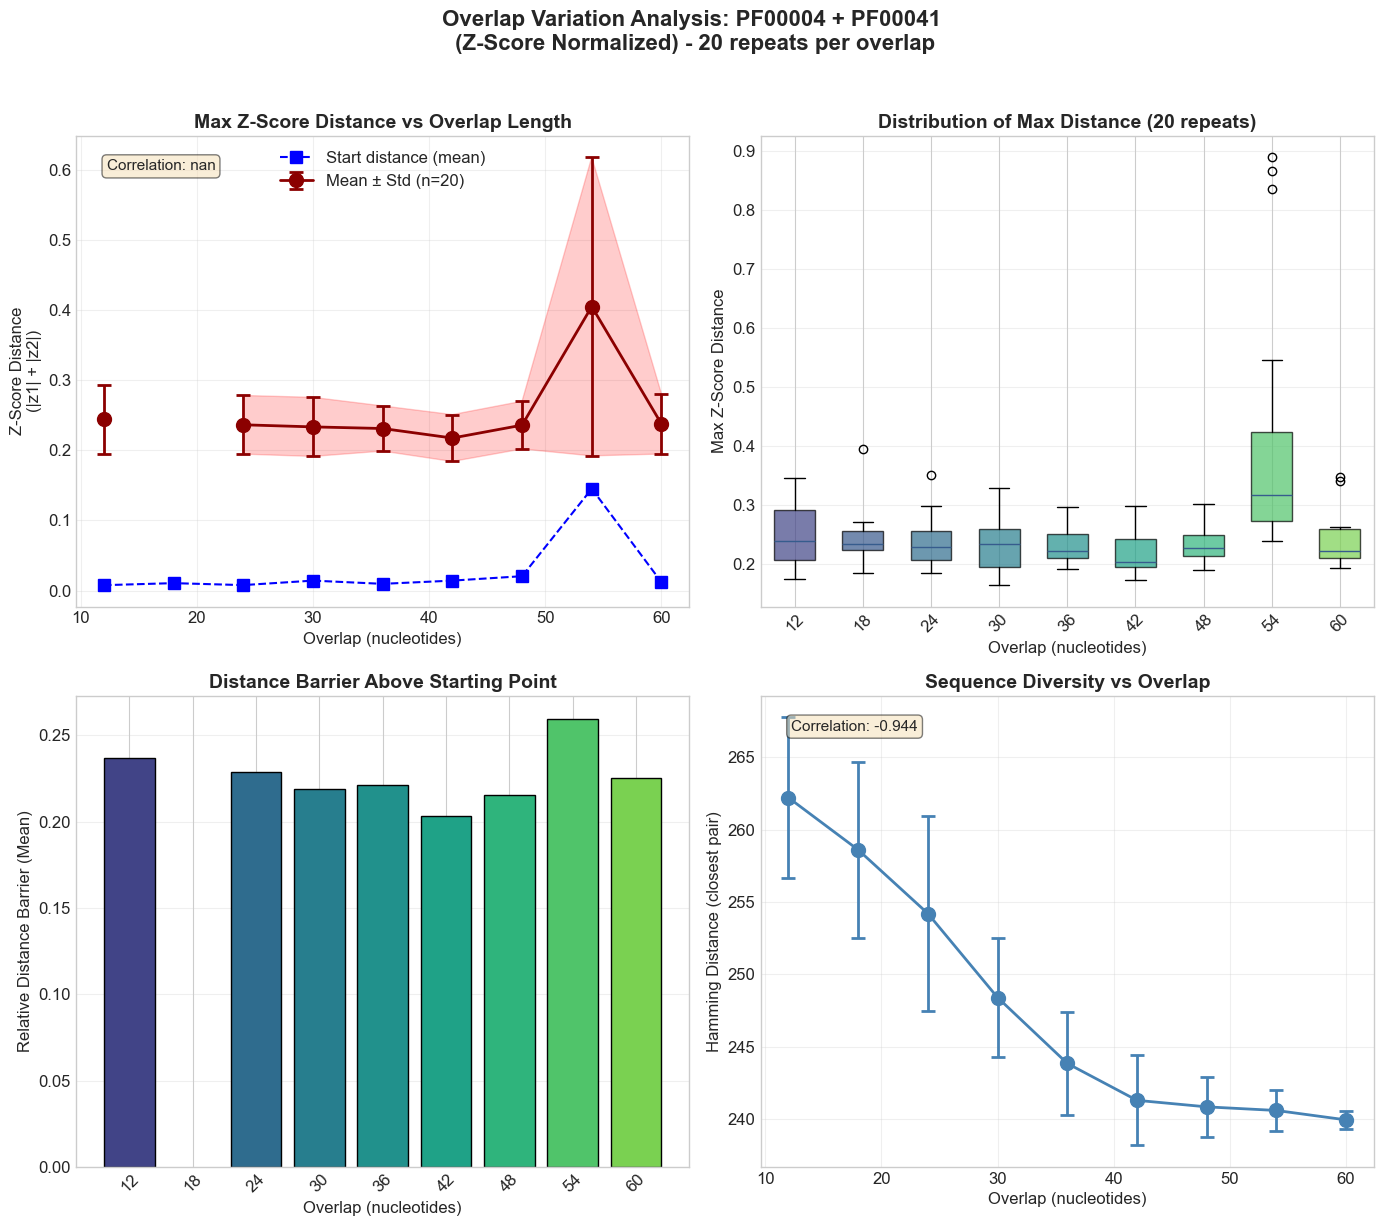

In [ ]:
if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results)))
    
    # Dynamic ylabel based on Z_SCORE setting
    dist_ylabel = "Z-Score Distance\n(|z1| + |z2|)" if Z_SCORE else "Distance from Natural\n(|E1-mean1| + |E2-mean2|)"
    
    # Plot 1: Max Distance from Natural vs Overlap (WITH ERROR BARS)
    ax1 = axes[0, 0]
    ax1.errorbar(overlaps, max_distances, yerr=max_dist_stds, fmt='o-', 
                 color='darkred', linewidth=2, markersize=10, capsize=5, capthick=2,
                 label=f'Mean ± Std (n={N_REPEATS})')
    ax1.fill_between(overlaps, 
                     [m - s for m, s in zip(max_distances, max_dist_stds)],
                     [m + s for m, s in zip(max_distances, max_dist_stds)],
                     alpha=0.2, color='red')
    ax1.plot(overlaps, start_distances, 's--', color='blue', linewidth=1.5, markersize=8, 
             label='Start distance (mean)')
    ax1.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax1.set_ylabel(dist_ylabel, fontsize=12)
    ax1.set_title(f'{MAX_DIST_LABEL} vs Overlap Length', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add correlation
    if len(overlaps) > 2:
        corr = np.corrcoef(overlaps, max_distances)[0, 1]
        ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax1.transAxes, 
                 fontsize=11, verticalalignment='top', 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Plot 2: Box plot of max distances across repeats
    ax2 = axes[0, 1]
    # Group raw data by overlap for box plot
    box_data = [valid_df[valid_df['overlap'] == ov]['max_distance_from_natural'].values 
                for ov in overlaps]
    bp = ax2.boxplot(box_data, positions=range(len(overlaps)), widths=0.6, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xticks(range(len(overlaps)))
    ax2.set_xticklabels([str(o) for o in overlaps], rotation=45)
    ax2.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax2.set_ylabel(MAX_DIST_LABEL, fontsize=12)
    ax2.set_title(f'Distribution of Max Distance ({N_REPEATS} repeats)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Relative Distance (barrier above starting point)
    ax3 = axes[1, 0]
    bars = ax3.bar(range(len(overlaps)), relative_distances, color=colors, edgecolor='black')
    ax3.set_xticks(range(len(overlaps)))
    ax3.set_xticklabels([str(o) for o in overlaps], rotation=45)
    ax3.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax3.set_ylabel('Relative Distance Barrier (Mean)', fontsize=12)
    ax3.set_title('Distance Barrier Above Starting Point', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Hamming distance vs Overlap with error bars
    ax4 = axes[1, 1]
    ham_dist_stds = summary['hamming_distance_std'].values
    ax4.errorbar(overlaps, ham_dists, yerr=ham_dist_stds, fmt='o-', 
                 color='steelblue', linewidth=2, markersize=10, capsize=5, capthick=2)
    ax4.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax4.set_ylabel('Hamming Distance (closest pair)', fontsize=12)
    ax4.set_title('Sequence Diversity vs Overlap', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # Add correlation for Hamming
    if len(overlaps) > 2:
        corr_ham = np.corrcoef(overlaps, ham_dists)[0, 1]
        ax4.text(0.05, 0.95, f'Correlation: {corr_ham:.3f}', transform=ax4.transAxes, 
                 fontsize=11, verticalalignment='top', 
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    z_score_text = " (Z-Score Normalized)" if Z_SCORE else " (Raw Energy Units)"
    plt.suptitle(f'Overlap Variation Analysis: {PROTEIN_1} + {PROTEIN_2}\n{z_score_text} - {N_REPEATS} repeats per overlap', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('overlap_variation_results.png', dpi=150, bbox_inches='tight')
    plt.show()

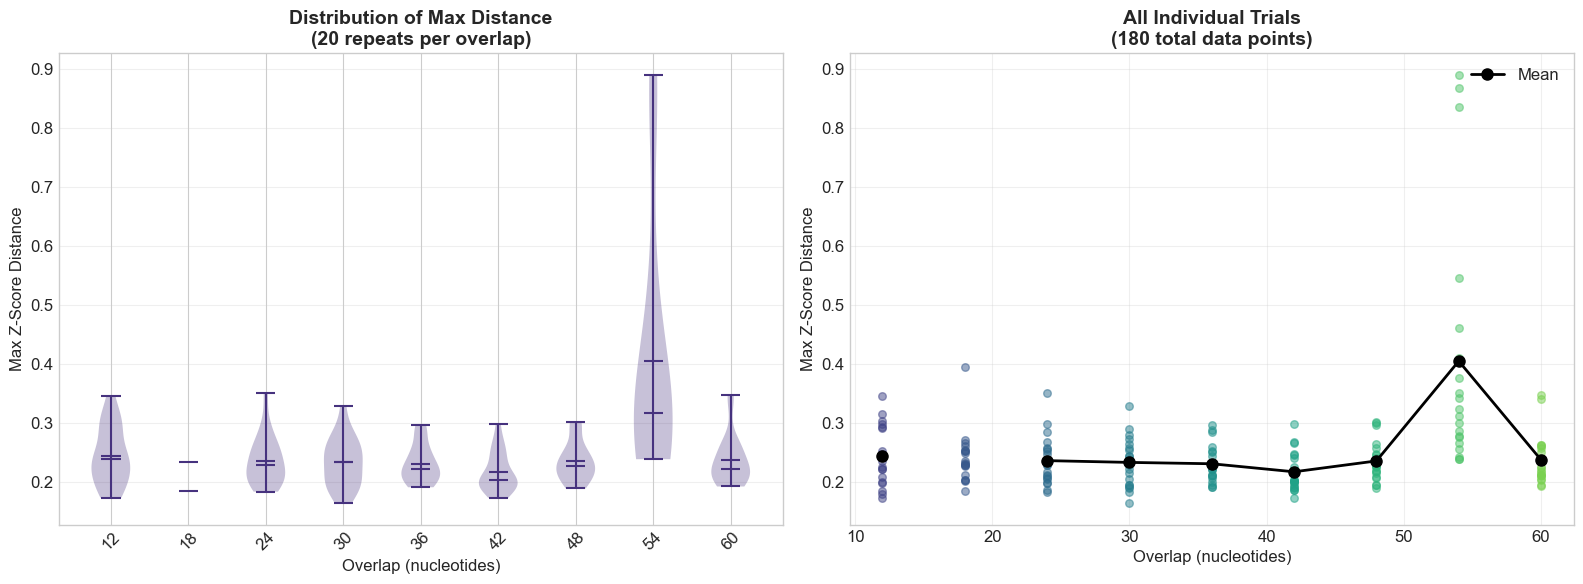

In [ ]:
if len(results) > 0:
    # Additional visualization: Violin plot showing full distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Violin plot of max distances
    ax1 = axes[0]
    parts = ax1.violinplot([valid_df[valid_df['overlap'] == ov]['max_distance_from_natural'].values 
                            for ov in overlaps], 
                           positions=range(len(overlaps)), showmeans=True, showmedians=True)
    ax1.set_xticks(range(len(overlaps)))
    ax1.set_xticklabels([str(o) for o in overlaps], rotation=45)
    ax1.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax1.set_ylabel(MAX_DIST_LABEL, fontsize=12)
    ax1.set_title(f'Distribution of Max Distance\n({N_REPEATS} repeats per overlap)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Scatter plot of all individual trials
    ax2 = axes[1]
    for i, ov in enumerate(overlaps):
        ov_data = valid_df[valid_df['overlap'] == ov]['max_distance_from_natural'].values
        ax2.scatter([ov] * len(ov_data), ov_data, alpha=0.5, s=30, color=colors[i])
    
    # Overlay mean line
    ax2.plot(overlaps, max_distances, 'ko-', linewidth=2, markersize=8, label='Mean')
    ax2.set_xlabel('Overlap (nucleotides)', fontsize=12)
    ax2.set_ylabel(MAX_DIST_LABEL, fontsize=12)
    ax2.set_title(f'All Individual Trials\n({len(valid_df)} total data points)', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('overlap_variation_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Save Results

In [ ]:
if len(results) > 0:
    # Save aggregated summary results
    summary_export = summary.copy()
    summary_export['protein_1'] = PROTEIN_1
    summary_export['protein_2'] = PROTEIN_2
    summary_export['nat_mean_1'] = mean_e1
    summary_export['nat_mean_2'] = mean_e2
    summary_export['n_repeats'] = N_REPEATS
    
    summary_export.to_csv('overlap_variation_summary.csv', index=False)
    print("Summary saved to overlap_variation_summary.csv")
    
    # Save raw trial-level results
    raw_df_export = valid_df.copy()
    raw_df_export['protein_1'] = PROTEIN_1
    raw_df_export['protein_2'] = PROTEIN_2
    raw_df_export['nat_mean_1'] = mean_e1
    raw_df_export['nat_mean_2'] = mean_e2
    
    raw_df_export.to_csv('overlap_variation_raw_trials.csv', index=False)
    print(f"Raw trial data saved to overlap_variation_raw_trials.csv ({len(valid_df)} trials)")
    
    # Also save legacy format for backward compatibility
    df_legacy = pd.DataFrame([{
        'overlap': r['overlap'],
        'hamming_distance': r['hamming_distance'],
        'n_mutations': r['n_mutations'],
        'max_distance_from_natural': r['max_distance_from_natural'],
        'max_distance_std': r.get('max_distance_std', np.nan),
        'start_distance': r['start_distance'],
        'end_distance': r['end_distance'],
        'relative_distance': r['max_distance_from_natural'] - r['start_distance'],
        'mean_e1': r['mean_e1'],
        'mean_e2': r['mean_e2'],
        'n_trials': r.get('n_trials', 1),
        'convergence_rate': r.get('convergence_rate', np.nan),
        'nat_mean_1': mean_e1,
        'nat_mean_2': mean_e2,
        'protein_1': PROTEIN_1,
        'protein_2': PROTEIN_2
    } for r in results])
    
    df_legacy.to_csv('overlap_variation_results.csv', index=False)
    print("Legacy format saved to overlap_variation_results.csv")
    
    print("\n=== Summary Table ===")
    display(summary_export[['overlap', 'max_distance_from_natural_mean', 'max_distance_from_natural_std', 
                            'max_distance_from_natural_min', 'max_distance_from_natural_max',
                            'hamming_distance_mean', 'ga_convergence_rate']])

Summary saved to overlap_variation_summary.csv
Raw trial data saved to overlap_variation_raw_trials.csv (180 trials)
Legacy format saved to overlap_variation_results.csv

=== Summary Table ===


,overlap,max_distance_from_natural_mean,max_distance_from_natural_std,max_distance_from_natural_min,max_distance_from_natural_max,hamming_distance_mean,ga_convergence_rate
0,12,0.2443,0.0490,0.1737,0.3457,262.20,1.00
1,18,inf,NaN,0.1851,inf,258.60,0.95
2,24,0.2363,0.0418,0.1837,0.3504,254.20,1.00
3,30,0.2333,0.0421,0.1639,0.3293,248.40,1.00
4,36,0.2310,0.0322,0.1912,0.2962,243.85,1.00
5,42,0.2174,0.0334,0.1734,0.2991,241.30,1.00
6,48,0.2358,0.0340,0.1892,0.3013,240.85,1.00
7,54,0.4049,0.2129,0.2387,0.8902,240.60,1.00
8,60,0.2375,0.0429,0.1925,0.3476,239.95,1.00


## 10. Statistical Analysis

In [ ]:
if len(results) >= 3:
    from scipy import stats
    
    print(f"Statistical Analysis ({N_REPEATS} repeats per overlap)")
    print("=" * 65)
    
    # Linear regression on means: max distance from natural vs overlap
    slope, intercept, r_value, p_value, std_err = stats.linregress(overlaps, max_distances)
    
    print("\n1. Linear Regression: Mean Max Distance vs Overlap")
    print("-" * 50)
    print(f"  Slope: {slope:.6f} (distance per nucleotide of overlap)")
    print(f"  Intercept: {intercept:.4f}")
    print(f"  R-squared: {r_value**2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Standard error: {std_err:.6f}")
    
    # Spearman correlation (more robust to outliers)
    spearman_corr, spearman_p = stats.spearmanr(overlaps, max_distances)
    print(f"\n  Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.4f})")
    
    # Analysis using all raw data points (not just means)
    print("\n2. Analysis on All Raw Data Points")
    print("-" * 50)
    all_overlaps = valid_df['overlap'].values
    all_distances = valid_df['max_distance_from_natural'].values
    
    slope_raw, intercept_raw, r_raw, p_raw, stderr_raw = stats.linregress(all_overlaps, all_distances)
    print(f"  Slope: {slope_raw:.6f}")
    print(f"  R-squared: {r_raw**2:.4f}")
    print(f"  P-value: {p_raw:.4f}")
    print(f"  N data points: {len(all_overlaps)}")
    
    # Weighted regression (weight by inverse variance)
    print("\n3. Weighted Regression (by 1/variance)")
    print("-" * 50)
    weights = 1.0 / (np.array(max_dist_stds) ** 2 + 1e-10)  # Avoid division by zero
    # Weighted least squares
    W = np.diag(weights)
    X = np.column_stack([np.ones(len(overlaps)), overlaps])
    y = np.array(max_distances)
    
    try:
        beta = np.linalg.lstsq(W @ X, W @ y, rcond=None)[0]
        print(f"  Weighted slope: {beta[1]:.6f}")
        print(f"  Weighted intercept: {beta[0]:.4f}")
    except:
        print("  (Weighted regression failed)")
    
    # Summary
    print("\n" + "=" * 65)
    print("CONCLUSION:")
    if p_value < 0.05 and slope > 0:
        print("  SIGNIFICANT positive relationship between overlap and distance.")
        print("  This supports the hypothesis that evolvability decreases with overlap.")
    elif p_raw < 0.05 and slope_raw > 0:
        print("  Significant trend found in raw data (p < 0.05).")
        print("  Suggests relationship exists but is noisy at the per-overlap level.")
    elif slope > 0 or slope_raw > 0:
        print("  Positive trend observed but NOT statistically significant.")
        print(f"  May need more repeats (currently {N_REPEATS}) to confirm.")
    else:
        print("  No clear positive relationship observed.")
        print("  The hypothesis is not supported by this data.")

## 11. Summary

### Hypothesis
Evolvability (ability to find evolutionary paths with low energy barriers) decreases as gene overlap increases.

### Method (with Statistical Repeats)
- For each overlap value, run **N_REPEATS independent trials** (configurable)
- Each trial:
  1. Generates a pool of functional overlapping sequences (tracked separately with progress/difficulty metrics)
  2. Finds the closest sequence pair (minimum Hamming distance)
  3. Uses Genetic Algorithm to find optimal mutation ordering
  4. Records the maximum energy barrier along the path
- **Sequence generation** is now separate from GA optimization, allowing progress tracking
- **Difficulty metrics** track how hard it is to generate valid pairs at each overlap

### Statistical Output
- Mean and standard deviation of max distance per overlap
- Box plots and violin plots showing full distributions
- Linear regression with p-values on both means and raw data
- Spearman correlation for robustness to outliers
- Generation difficulty analysis by overlap

### Interpretation
- Higher energy barriers mean more difficult evolutionary transitions
- Error bars and distributions show confidence in measurements
- Statistical tests determine if the overlap-barrier relationship is significant
- Difficulty metrics reveal if certain overlaps are harder to sample